# Connectomics Module 1: Neuron-centered connectomics

The function of the nervous system arises out of a combination of the properties of individual neurons and the properties of how they are connected into a larger network. The central goal of <b>connectomics</b> is to produce complete maps of the connectivity of the nervous system with synaptic resolution and analyze them to better understand the organization, development, and function of the nervous system.

Electron Microscopy (EM) data enables morphological reconstruction of neurons and resolution of their synaptic connectivity </b>. The V1DD dataset is one of the largest volume EM datasets currently available, and spans all layers of mouse visual cortex. We will be using this dataset to query the connectivity between neurons in the visual cortex.

The V1DD dataset is newly public. </b> Previous years of this course have used the [MICrONS Dataset](https://www.microns-explorer.org/), which is also a cubic millimeter volume of mouse visual cortex. Both datasets are available for the use of this course, but we will cover V1DD in Week 1.

Module 1 of this workshop will:

* introduce the basics of how synaptic connectivity is measured in EM connectomics
* examine reconstructions of individual neurons and their connectivity
* discuss how morphological features and connectivity suggest cell types
* explore how connectivity changes as function of target and distance

Module 2 of this workshop will:

* introduce concepts of network connectivity
* investigate the role of cell type in the structure of networks
* consider connection probability as a function of distance
* incorporate ophys recordings and map the correlation of structure to function


In [1]:
import sys
from os.path import join as pjoin
import platform

# Add the directory for the data and utilities
mat_version = 1196

platstring = platform.platform()
system = platform.system()
if system == "Darwin":
    # macOS
    data_root = "/Volumes/Brain2026/"
elif system == "Windows":
    # Windows (replace with the drive letter of USB drive)
    data_root = "E:/"
elif "amzn" in platstring:
    # then on CodeOcean
    data_root = "/data/"
else:
    # then your own linux platform
    # EDIT location where you mounted hard drive
    data_root = "/media/$USERNAME/Brain2026/"

# Set the directory to load prepared data and utility code
data_dir = pjoin(data_root, "v1dd_1196_ccm")
known_neurons = "v1dd_1196_proofread_dendrites"

In [2]:
# Import packages
import pandas as pd
import numpy as np
import polars as pl
from connects_common_connectivity.io import DatasetReader

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## CAVE account setup

In order to manage server traffic, every user needs to create a CAVE account and download a user token to access CAVE's services programmatically. The CAVE infrastructure can be read about in more detail in the [MICrONS Nature Package](https://doi.org/10.1038/s41592-024-02426-z).

**A Google account (or Google-enabled account) is required to create a CAVE account.**

Run the cell below and follow the set up instructions; enter the token first, then enter 'y' when prompted

In [3]:
from caveclient import CAVEclient

# Token Generation and Setup
CAVEclient.setup_token("https://global.em.brain.allentech.org")

# Initialize CAVEclient
client = CAVEclient(datastack_name="v1dd_public")

/opt/conda/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.2.2) or chardet (7.5.1)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(


Visit https://global.em.brain.allentech.org/sticky_auth/settings/tokens and copy an existing token or create a new one.


Paste your auth token (input will be hidden):  ········
Set all of your datastacks to use this token and server ('Y', recommended), specify individual datastacks ('n'), or finish now ('exit'). (Y/n/exit)  y


All datastacks are configured to use this server address.
You will not need to specify a server address when initializing a client for configured datastacks in the future.
Setup complete!


**Tip for CodeOcean users:** you can add the the CAVEclient token to your capsule's secrets, so you do not have to enter it every time you run the notebook. If you chose to use EM data for your project in Week 2, [check out the DataBook for instruction](https://allenswdb.github.io/anatomy/microns-em/em-caveclient-setup.html#codeocean-token-setup)

## Neuron morphology: representing neurons as skeletons

Often in thinking about neurons, you want to measure things along a linear dimension of a neuron.

However, the segmentation and meshes are a complex 3D shape that makes this non-trivial. There are methods for reducing the shape of a segmented neuron down to a linear tree like structure usually referred to as a **skeleton**. CAVE `Skeleton Service` automatically generates skeletons for a large number of cells in the dataset, and make the skeleton generation available on demand.

*Note*: The meshes you see in Neuroglancer are available to download through the python client `cloud-volume`, and can be loaded for analysis and visualization in other tools. This is useful for some types of analysis (and for making beautiful renders of neurons), but we will not cover that in this course.

Now we will select one neuron based on its root_id, the 18-digit number you see in neuroglancer (like we will do later)

In [4]:
import ossify

# Load basic cell (skeleton + L2 graph)
root_id = 864691132534315610 # Known example neuron. You may iterate later. 

cell = ossify.load_cell_from_client(
    root_id=root_id,
    client=client,
)

print(f"Loaded cell {cell.name}")
print(f"Skeleton: {cell.skeleton.n_vertices} vertices")

Loaded cell 864691132534315610
Skeleton: 3567 vertices


The python package `ossify` provides skeleton downloading, processing, analysis, and many convenience functions. Including loading cells directly from connectomics databases using CAVEclient. For documentation, see [Ossify](https://csdashm.com/ossify/).

Then we can use the `plot_morphology_2d` function to visualize our neuron in two dimensions:

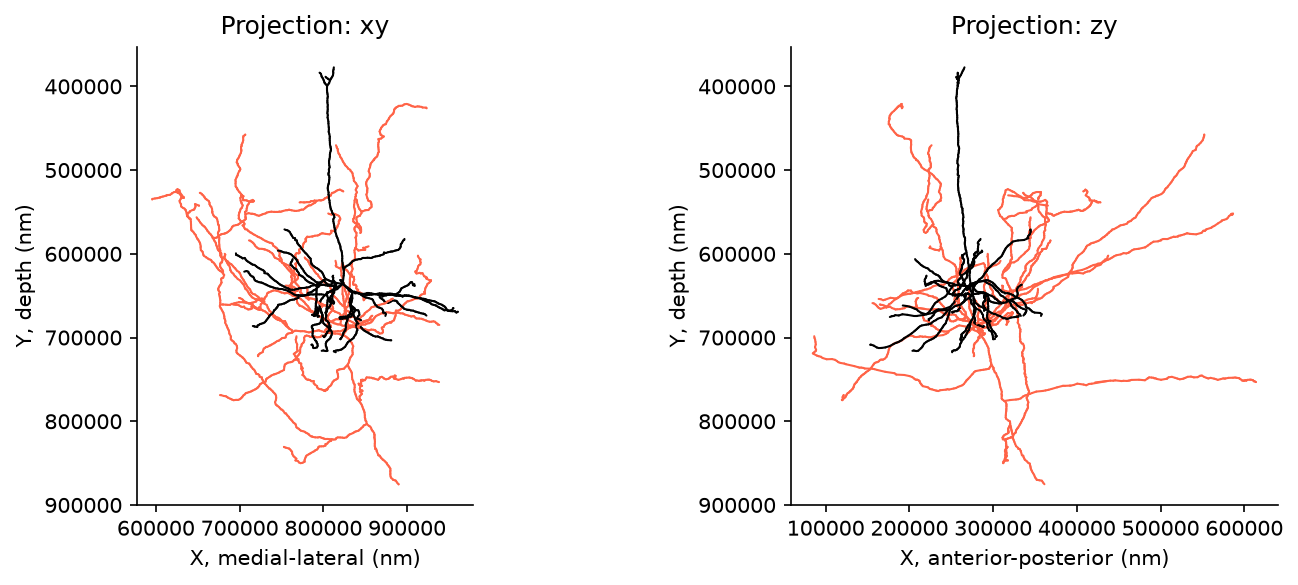

In [5]:
# Figure 1: Skeleton representation in 2D

# Plot different 2D projections
projections = ["xy", "zy"] # , 'xz']
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

for i, proj in enumerate(projections):
    ossify.plot.plot_morphology_2d(
        cell,
        projection=proj,
        color="compartment",
        palette={1: 'navy', 2: 'tomato', 3: 'black'}, # color scheme for axon, dendrite
        ax=axes[i]
    )
    axes[i].set_title(f"Projection: {proj}")
    axes[i].set_ylabel(f"(nm)")
    axes[i].set_xlabel(f"(nm)")
    axes[i].set_aspect("equal")

# Add labels for the anatomical orientation
axes[0].set(xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')
axes[1].set(xlabel='X, anterior-posterior (nm)', ylabel='Y, depth (nm)')
sns.despine()
plt.tight_layout()
plt.show()

#### Transformed coordinate system

A note on the coordinate system: the 'native resolution' for V1DD is in units of *voxels*. The data you will see in neuroglancer is in 'native' Voxel space where each coordinate is in the thousands. Not only are these units large, the offset is arbitrar. It makes much more sense to anchor y=0 to the pial surface. But when working with data analysis, we want a more comprehensible numbers for comparison.

The skeleton above is plotted in **nanometer coordinates**, which differs from neuroglancer. In general, there are three types of coordinates you may encounter and it is worth being deliberate in which system you use.

1. <b>Voxel coordinates</b> are the coordinates of a point in the original image volume. These are the coordinates that are used to index into the volumes you can see in Neuroglancer, but each number has a potentially different unit. In the V1DD data, a voxel is 9 nm wide in the x and y directions, and 45 nm long in the z direction. This means that a 1x1x1 micron cube would be represented by a ~110x110x20 voxel span. Annotations (such as synapses) are stored in voxel coordinates.
2. <b>Nanometer coordinates</b> are the coordinates of a point in the original image volume, but in nanometers. This is equivalent to the voxel coordinate multiplied by the voxel resolution, with no further transformation applied. Mesh and skeleton vertices are stored in nanometer coordinates.
3. <b>Transformed coordinates</b> reflect a trasnsformation that has been applied to the original image volume. This transformation is a rotation to make the pia surface as flat as possible, a translation to move the pial surface to y=0, and a scaling to bring coordinates into microns. Transformed coordinates are convenient for more accurate computations of depth and the pia-to-white-matter axis, but are not stored by default.For documentation, see [Standard Transform](https://caveconnectome.github.io/standard_transform/).

### Adding synapse positions to skeleton

Synapses are automatically detected and assigned in the dataset. That means we 'know' all of the inputs to and outputs from our cell of interest. Let's collect that data:

**Note** this cell may take a minute to run. It is pulling more data than the previous code `load_cell` call

In [5]:
# Load skeleton with synaptic features
root_id = 864691132534315610 # Known example neuron. You may iterate later. 

cell = ossify.load_cell_from_client(
    root_id=root_id,
    client=client,
    synapses=True, # optional argument to load synapses with skeleton
    include_partner_root_id=True, # optional argument to load partner root ids with synapses
)

print(f"Loaded cell {cell.name}")
print(f"Skeleton: {cell.skeleton.n_vertices} vertices")

# All annotations in the cell
cell.annotations.describe()

Loaded cell 864691132534315610
Skeleton: 3567 vertices
# Annotations (2)
├── pre_syn (PointCloudLayer)
│   ├── 673 vertices
│   ├── features: [created, deleted, post_pt_position_x, post_pt_position_y, post_pt_position_z, post_pt_root_id, 
│       post_pt_supervoxel_id, pre_pt_l2_id, pre_pt_position_x, pre_pt_position_y, pre_pt_position_z, pre_pt_root_id, 
│       pre_pt_supervoxel_id, size]
│   └── Links: graph <-> pre_syn
└── post_syn (PointCloudLayer)
    ├── 1091 vertices
    ├── features: [created, deleted, post_pt_l2_id, post_pt_position_x, post_pt_position_y, post_pt_position_z, 
│       post_pt_root_id, post_pt_supervoxel_id, pre_pt_position_x, pre_pt_position_y, pre_pt_position_z, pre_pt_root_id, 
│       pre_pt_supervoxel_id, size]
    └── Links: graph <-> post_syn


In [6]:
# Show the synapse dataframe attached to skeleton
pre_syn_df = cell.annotations.pre_syn.nodes
post_syn_df = cell.annotations.post_syn.nodes

# return the available columns to line
print(pre_syn_df.columns)

pre_syn_df.head(3)

Index(['created', 'deleted', 'pre_pt_position_x', 'pre_pt_position_y',
       'pre_pt_position_z', 'post_pt_position_x', 'post_pt_position_y',
       'post_pt_position_z', 'ctr_pt_position_x', 'ctr_pt_position_y',
       'ctr_pt_position_z', 'size', 'pre_pt_supervoxel_id', 'pre_pt_root_id',
       'post_pt_supervoxel_id', 'post_pt_root_id', 'pre_pt_l2_id'],
      dtype='object')


,created,deleted,pre_pt_position_x,pre_pt_position_y,pre_pt_position_z,post_pt_position_x,post_pt_position_y,post_pt_position_z,ctr_pt_position_x,ctr_pt_position_y,ctr_pt_position_z,size,pre_pt_supervoxel_id,pre_pt_root_id,post_pt_supervoxel_id,post_pt_root_id,pre_pt_l2_id
id,,,,,,,,,,,,,,,,,
402558233,2021-11-18 22:05:28.270700+00:00,NaT,839602,564646,228735,839515,565160,229410,839699.0,565034.0,229095.0,3881.0,93320500256229717,864691132534315610,93320568975740637,864691132726874269,165378094293583076
292446107,2021-11-18 22:06:23.833563+00:00,NaT,675478,569525,361440,675333,569700,361125,675469.0,569603.0,361305.0,1082.0,88676300981986694,864691132534315610,88676300981976915,864691132620269499,160733895019463949
438169048,2021-11-18 22:08:20.896586+00:00,NaT,865899,475571,202005,865725,476095,202230,865695.0,475872.0,202005.0,5146.0,94021782449115055,864691132534315610,94021782449121473,864691132569299996,166079376486565024


### Examine the synapses for a cell of interest

Now we have all the inputs and outputs to thise cell.


In [8]:
post_syn_df.head(3)[['pre_pt_root_id','post_pt_root_id','size','ctr_pt_position_x','ctr_pt_position_y','ctr_pt_position_z']]

,pre_pt_root_id,post_pt_root_id,size,ctr_pt_position_x,ctr_pt_position_y,ctr_pt_position_z
id,,,,,,
405315773,864691131677275322,864691132534315610,1707.0,830717.0,643333.0,308385.0
395011063,864691132921086475,864691132534315610,465.0,815770.0,577247.0,265140.0
440332672,864691132578941970,864691132534315610,933.0,872738.0,655322.0,304470.0


In [9]:
pre_syn_df.head(3)[['pre_pt_root_id','post_pt_root_id','size','ctr_pt_position_x','ctr_pt_position_y','ctr_pt_position_z']]

,pre_pt_root_id,post_pt_root_id,size,ctr_pt_position_x,ctr_pt_position_y,ctr_pt_position_z
id,,,,,,
402558233,864691132534315610,864691132726874269,3881.0,839699.0,565034.0,229095.0
292446107,864691132534315610,864691132620269499,1082.0,675469.0,569603.0,361305.0
438169048,864691132534315610,864691132569299996,5146.0,865695.0,475872.0,202005.0


#### Exercise 1: What is input or output? How can we tell?

!BD to do: belabor this point

In [12]:
input_df = post_syn_df
output_df = pre_syn_df

#### Plot synapses on skeleton

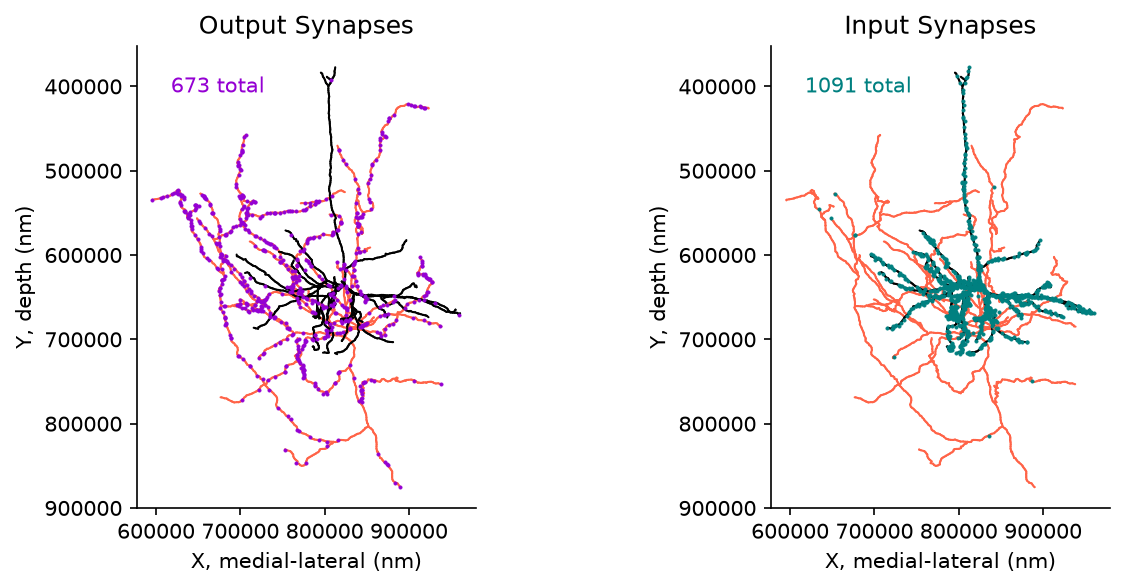

In [14]:
# Figure 2: Skeleton with synaptic inputs and outputs

fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

for i in range(2):
    ossify.plot.plot_morphology_2d(cell,
                                   projection="xy",
                                   color="compartment",
                                   palette={1: 'navy', 2: 'tomato', 3: 'black'},
                                   ax=ax[i])

# Output synapses
sns.scatterplot(data=output_df, x="ctr_pt_position_x", y="ctr_pt_position_y",
                s=3, color="darkviolet", ax=ax[0], edgecolor=None, zorder=100)
ax[0].text(.1,.9,f'{len(output_df)} total', color='darkviolet',  transform = ax[0].transAxes)


# Input synapses
sns.scatterplot(data=input_df, x="ctr_pt_position_x", y="ctr_pt_position_y",
                s=3, color="teal", ax=ax[1], edgecolor=None, zorder=100)
ax[1].text(.1,.9, f'{len(input_df)} total', color='teal',  transform = ax[1].transAxes)

ax[0].set(title="Output Synapses", xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')
ax[1].set(title="Input Synapses", xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')

sns.despine()
plt.show()

Tip for analysis: We could also have gotten the same thing (synapses for our cell of interest), without getting the skeleton, as follows:

```
# Inputs synapses: Query synapse table with synapse_query()
post_syn_df = client.materialize.synapse_query(post_ids=root_id)

# Output synapses: Query synapse table with synapse_query()
pre_syn_df = client.materialize.synapse_query(pre_ids=root_id)

```

The `synapse_query` function allows you to query the synapse table in a more convenient way than most other tables.
In particular, the `pre_ids` and `post_ids` let you specify which root id (or collection of root ids) you want to query, with pre_ids indicating the collection of **presynaptic neurons** and post_ids the collection of **postsynaptic neurons**.

Using both `pre_ids` and `post_ids` in one call is effectively a logical AND, returning only those synapses from neurons in the list of `pre_ids` that target neurons in the list of `post_ids`.

### Aggregating synapses to unique connections

Note that synapse queries always return the list of every synapse between the neurons in the query, even if there are multiple synapses between the same pair of neurons.

A common pattern to generate a list of connections between unique pairs of neurons is to group by the root ids of the presynaptic and postsynaptic neurons and then count the number of synapses between them.
For example, use `pandas.groupby()` to get the number of synapses from this neuron onto every other neuron:

In [30]:
# get count of synapses between presynaptic and postsynaptic partners
output_connectivity = (pre_syn_df.groupby(['pre_pt_root_id', 'post_pt_root_id'])
 ["size"].agg(['count'])
 .rename(columns={'count': 'syn_count'})
 .sort_values( by='syn_count', ascending=False,)
)

output_connectivity
# Note that the 'size' part here is just a way to quickly extract one column. This could be any of the remaining column names.

syn_count
pre_pt_root_id     post_pt_root_id              
864691132534315610 864691132708393766          6
                   864691132748924877          5
                   864691132782212618          5
                   864691133066825032          5
                   864691132605839533          4
...                                          ...
                   864691132252788418          1
                   864691132266513468          1
                   864691132287392351          1
                   864691132292351470          1
                   864691132239320617          1

[601 rows x 1 columns]

#### Exercise 2: aggregate input connectivity

Copy paste to generate the 'input connectivity' instead of output connectivity. Which column is held constant?

In [ ]:
input_connectivity = 'your input here'

#### Exercise 3: aggregate to get the 'sum' of synapse size instead

Number of synapses between neurons is one measure of synaptic strength. But in some cases **synapse size**, specifically the sum total of synapse active zone, may be more meaningful. Calculate the **output connectivity as a measure of `sum(size)`**:

In [32]:
output_connectivity_sum_size = 'your input here'

syn_count     sum
pre_pt_root_id     post_pt_root_id                      
864691132534315610 864691132708393766          6  9473.0
                   864691132748924877          5  5705.0
                   864691132782212618          5  6831.0
                   864691133066825032          5  6812.0
                   864691132605839533          4  2567.0
...                                          ...     ...
                   864691132252788418          1  2645.0
                   864691132266513468          1   562.0
                   864691132287392351          1   688.0
                   864691132292351470          1  2386.0
                   864691132239320617          1  1170.0

[601 rows x 2 columns]

### Proofreading considerations for inputs vs outputs

! BD TODO: add diagram here from slides

There are many reconstruction 'errors' or artifacts in the data. Some of these are 'merge' errors where multiple axons are merged together, or a glial cell is merged to a neurite.

Some of these are 'truncation' errors, where the axon ends before it should be. These two kinds of errors impact analysis differently. While split errors reduce the number of correct synaptic connections, merge errors add incorrect connections.

The frequency of errors is roughly related to the size, and so axons and dendrites have extremely different error profiles. 

* Dendrites, because they are thicker, are largely correct. **Most dendrites in the dataset are connected to their soma**.
* In contrast, axons, because they are thinner, have many more errors of both kinds. **Most axons in the dataset are NOT connected to their soma, without manual proofreading**.

Let's look at what that asymmetry means for what we know about our neuron's inputs and outputs:

In [35]:
## get the root_ids that have a "known" soma

# CAVEquery the nucleus lookup table
soma_df= client.materialize.views.nucleus_alternative_lookup().query(
    select_columns = ['id','pt_root_id']
)

# Data cleaning: drop duplicates on `pt_root_id`. These 'multisoma' objects make interpretation difficult.
soma_df = soma_df.drop_duplicates(subset='pt_root_id')

# Filter output synapses to known postsynaptic cells
pre_syn_to_known_df = pre_syn_df.loc[pre_syn_df.post_pt_root_id.isin(soma_df.pt_root_id)]

# Filter input synapses from known postsynaptic cells
post_syn_from_known_df = post_syn_df.loc[post_syn_df.pre_pt_root_id.isin(soma_df.pt_root_id)]

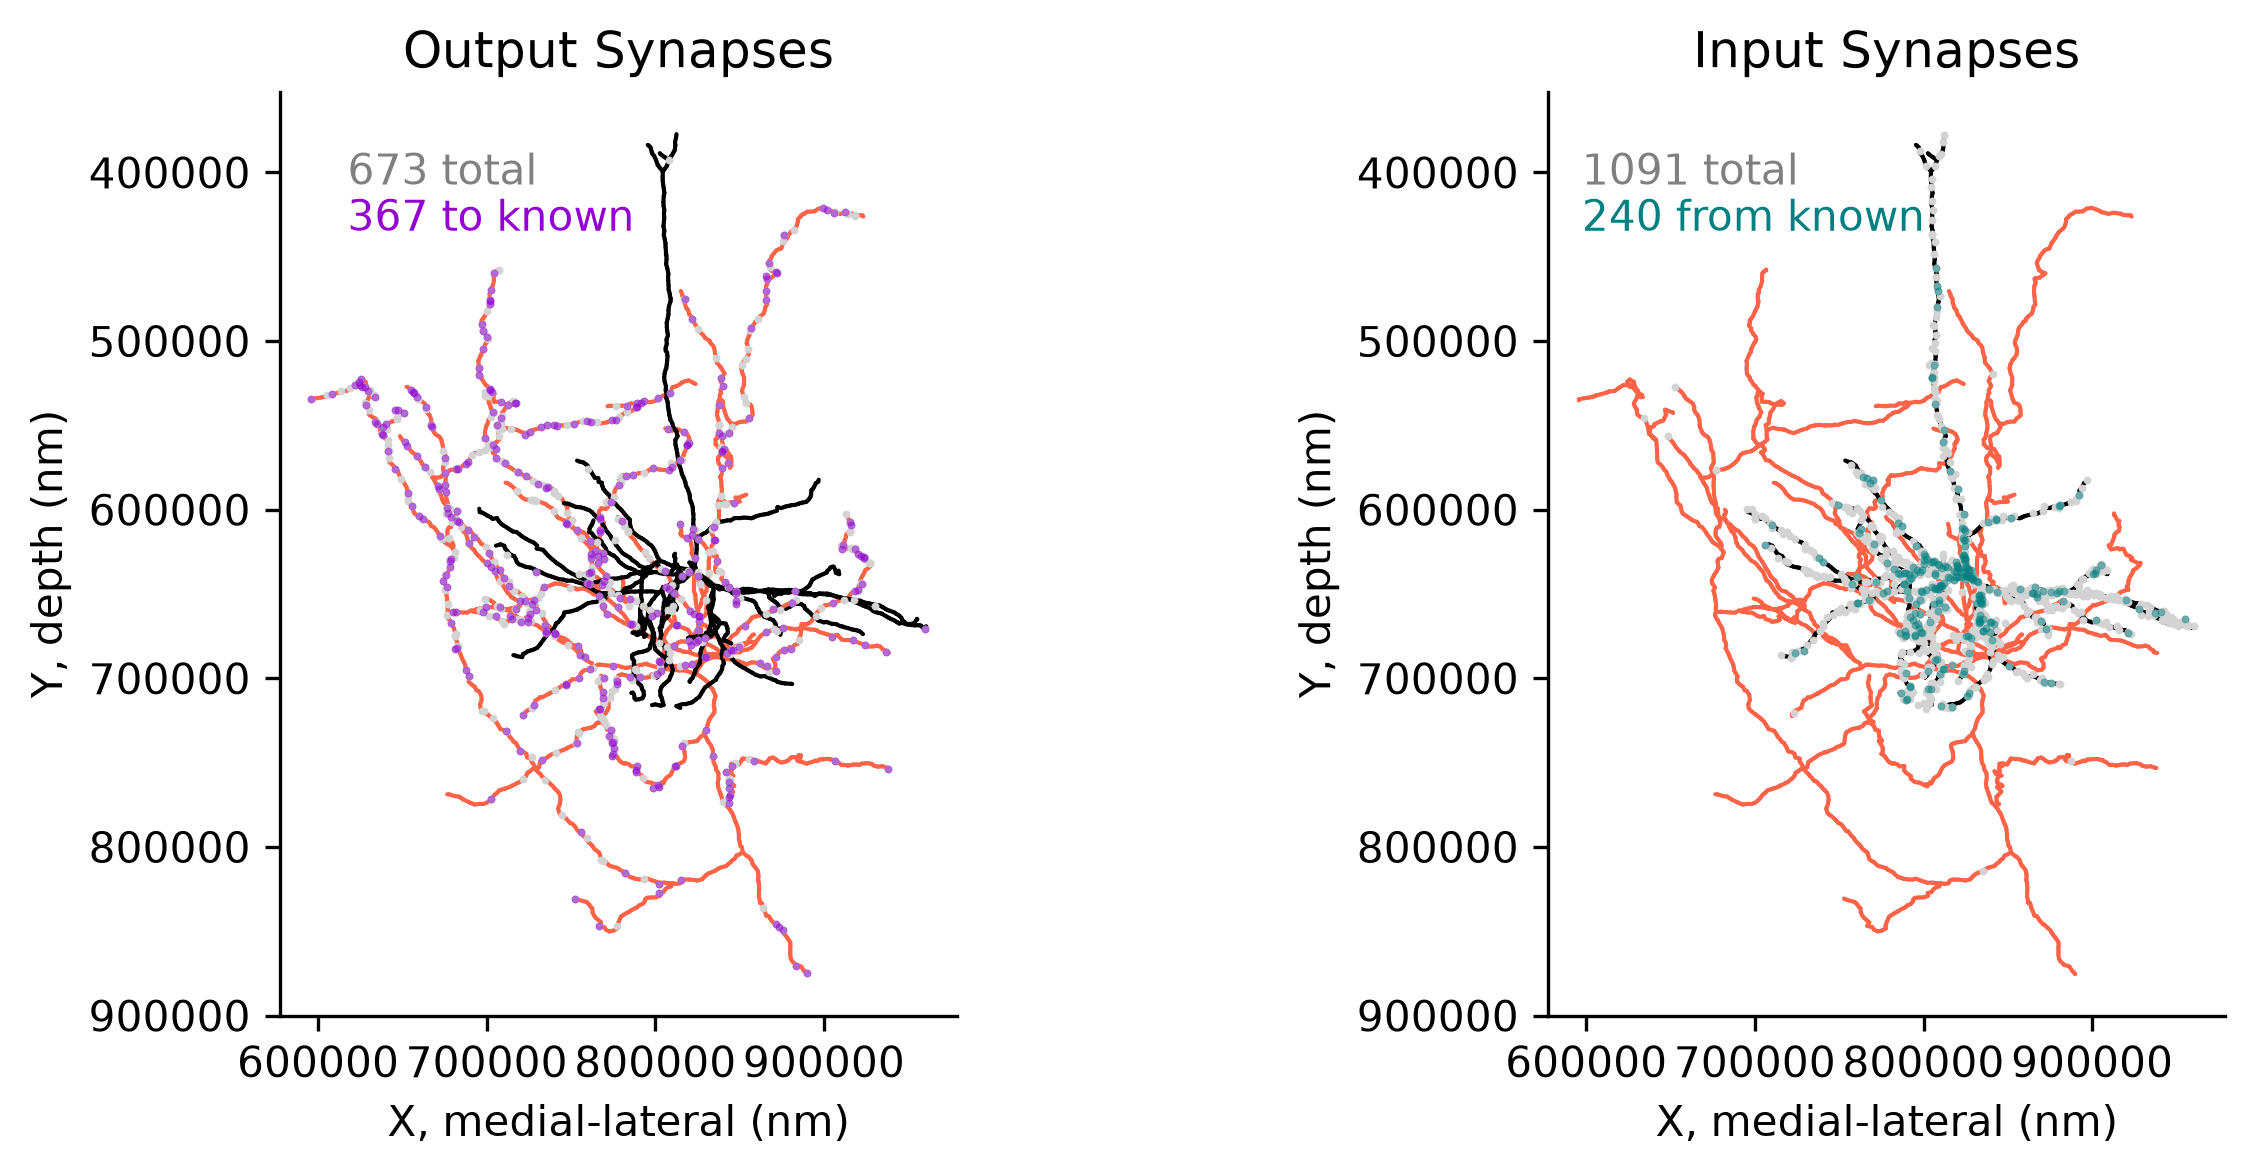

In [36]:
# Figure 3: Skeleton with inputs and outputs, filtered by 'known' connections

fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=300)

point_size = 3

for i in range(2):
    ossify.plot.plot_morphology_2d(cell,
                                   projection="xy",
                                   color="compartment",
                                   palette={1: 'navy', 2: 'tomato', 3: 'black'},
                                   ax=ax[i])
# Output synapses
sns.scatterplot(data=pre_syn_df, x="ctr_pt_position_x", y="ctr_pt_position_y",
                s=point_size, color="lightgrey", ax=ax[0], edgecolor=None, zorder=100)
sns.scatterplot(data=pre_syn_to_known_df, x="ctr_pt_position_x", y="ctr_pt_position_y",
                s=point_size, color="darkviolet", ax=ax[0], edgecolor=None, zorder=100, alpha=0.5)
ax[0].text(.1,.9,f'{len(pre_syn_df)} total', color='grey',  transform = ax[0].transAxes)
ax[0].text(.1,.85,f'{len(pre_syn_to_known_df)} to known', color='darkviolet',  transform = ax[0].transAxes)

# Input synapses
sns.scatterplot(data=post_syn_df, x="ctr_pt_position_x", y="ctr_pt_position_y",
                s=point_size, color="lightgrey", ax=ax[1], edgecolor=None, zorder=100)
sns.scatterplot(data=post_syn_from_known_df, x="ctr_pt_position_x", y="ctr_pt_position_y",
                s=point_size, color="teal", ax=ax[1], edgecolor=None, zorder=100, alpha=0.5)
ax[1].text(.05,.9,f'{len(post_syn_df)} total', color='grey',  transform = ax[1].transAxes)
ax[1].text(.05,.85,f'{len(post_syn_from_known_df)} from known', color='teal',  transform = ax[1].transAxes)

ax[0].set(title="Output Synapses", xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')
ax[1].set(title="Input Synapses", xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')
sns.despine()
plt.show()

### Synapse target compartment

Different synapses can target different compartments on the post synaptic cell: **dendritic spine, dendritic shaft, or soma**.

<p><img src="https://raw.githubusercontent.com/AllenInstitute/connectomics_at_cosyne/refs/heads/main/docs/resources/sss-diagram.png" width="600"> 

<center> Diagram and synapse compartment classification from: <a href=https://www.biorxiv.org/content/10.64898/2026.02.19.706834v1>A quantitative census of millions of postsynaptic structures in a large electron microscopy volume of mouse visual cortex (Pedigo et al.) </a> </center>

Synapses on a dendritic spine effect the membrane potential of a much smaller, isolated volume that decays to baseline slower. And so excitatory (glutamatergic) inputs have the possibility of 'summating' with multiple inputs nearby into a larger membrane potential that may initiate an action potential.

Whereas synapses onto the soma of neurons are especially strong for 'shunting' membrane potential, stopping axons potentials from triggering, and are almost exlusively inhibitory (GABAergic) synapses.

These annotaitons are available as CAVE table: `synapse_target_predictions_ssa`.

Let's visualize this for out **example neuron** from Part 1:

The basic querying logic of CAVE is `client.materialize.tables`. This takes a table of interest, for us `synapse_target_predictions_ssa` and queries the information requested from the server:


In [37]:
# Synapse dataframe attached to skeleton
pre_syn_df = cell.annotations.pre_syn.nodes
post_syn_df = cell.annotations.post_syn.nodes

# Add spine information to outputs
output_synapse_tags = client.materialize.tables.synapse_target_predictions_ssa(id=pre_syn_df.index).query(
    select_columns={'synapses_v1dd': ['id'], # reference id for synapse table
                    'synapse_target_predictions_ssa': ['tag'], # compartment label
                   }
).set_index('id')

pre_syn_df = (pre_syn_df.merge(output_synapse_tags, left_index=True, right_index=True, how='left')
              .rename(columns={'tag': 'Target'})
              .fillna({'Target': 'none'})
             )

# Add spine information to inputs
input_synapse_tags = client.materialize.tables.synapse_target_predictions_ssa(id=post_syn_df.index).query(
    select_columns={'synapses_v1dd': ['id'], # reference id for synapse table
                    'synapse_target_predictions_ssa': ['tag'], # compartment label
                   }
).set_index('id')

post_syn_df = (post_syn_df.merge(input_synapse_tags, left_index=True, right_index=True, how='left')
               .rename(columns={'tag': 'Target'})
               .fillna({'Target': 'none'})
             )


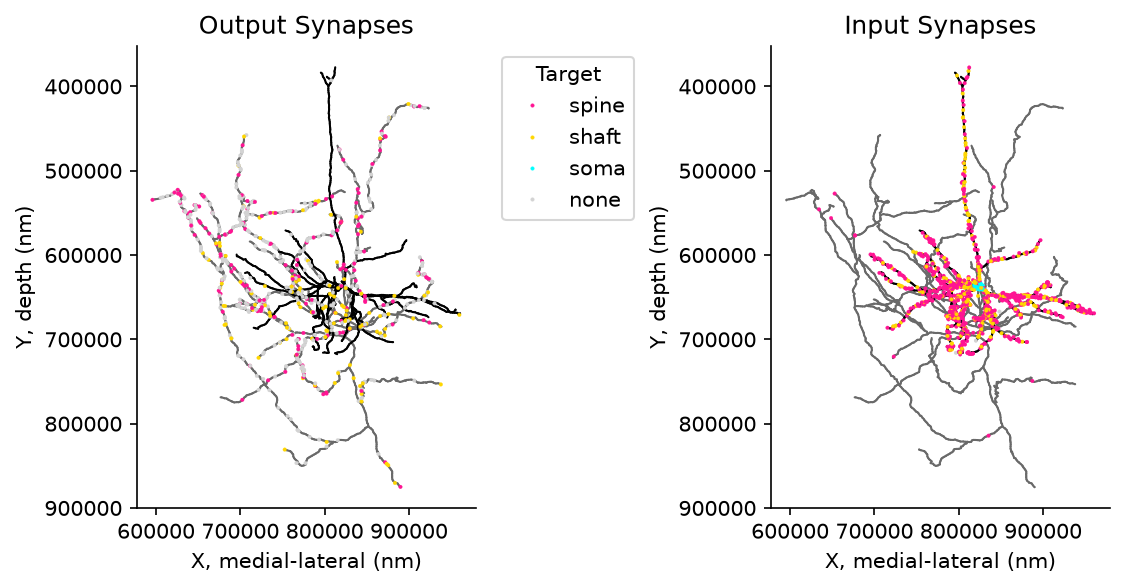

In [38]:
# Figure 4: Synaptic target compartments: spine, shaft, soma

fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

point_size = 3

for i in range(2):
    ossify.plot.plot_morphology_2d(cell,
                                   projection="xy",
                                   color="compartment",
                                   palette={1: 'navy', 2: 'dimgrey', 3: 'black'},
                                   ax=ax[i])
# Output synapses
sns.scatterplot(data=pre_syn_df, x="ctr_pt_position_x", y="ctr_pt_position_y",
                s=point_size, hue='Target', hue_order=['spine','shaft','soma','none'],
                palette={'spine': 'deeppink','shaft': 'gold', 'soma':'cyan', 'none': 'lightgrey'},
                ax=ax[0], edgecolor=None, zorder=100)


# Input synapses
sns.scatterplot(data=post_syn_df, x="ctr_pt_position_x", y="ctr_pt_position_y",
                s=point_size, hue='Target', hue_order=['spine','shaft','soma','none'],
                palette={'spine': 'deeppink','shaft': 'gold', 'soma':'cyan', 'none': 'lightgrey'},
                ax=ax[1], edgecolor=None, zorder=100,
                legend=False) 


ax[0].set(title="Output Synapses", xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')
ax[1].set(title="Input Synapses", xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')
sns.move_legend(ax[0], "upper right", bbox_to_anchor=(1.5, 1))
sns.despine()
plt.show()

! BD to do: explain None in this case. build some cell type intuition for targeting

## Morphological cell types

! BD TODO: add figures from slide here

Identifying the putative ‘cell type’ from the EM morphology is a process that involves both manual and automatic classifications. Subsets of the dataset have been manually classified by anatomists at the Allen Institute, and these ground truth labels used to train and refine different automated ‘feature classifiers’ over time.

The diversity of manual and automated cell type classifications available in the dataset reflect the fact that definitions of ‘cell types’ in the dataset is an active area of research and must be contextualized against the purpose and resolution of the cell-typing being performed.

Two of the most predictive features for broad cell type are:

* Soma location (in units of depth from pial surface). This captures cortical layer diversity
* Soma size (in units of volume). This is a strong proxy of many types of cell morpholigical diversity

For this, we will load the cell type information from the Common Connectivity Matrix (CCM) data asset. We will describe the data format more in the afternoon.

In [54]:
# Initialize the Common Connectivity dataset reader
reader = DatasetReader(data_dir)

v1dd_1196_proofread_dendrites

cell_df = (reader.read_dataset(known_neurons, featuresets=['v1dd_soma_spatial'], clustersets="v1dd_cell_types",)
    # .drop_nulls()
    .with_columns(pl.col("dataitem_id").cast(pl.UInt64),)
    .rename({"dataitem_id" : "pt_root_id",
             "v1dd_cell_types_level_1": "cell_type_coarse",
             "v1dd_cell_types_level_2": "cell_type"})
    .to_pandas()
)

cell_df[['pt_root_id','soma_transformed_y','soma_volume','cell_type_coarse','cell_type']].head()

,pt_root_id,soma_transformed_y,soma_volume,cell_type_coarse,cell_type
0,864691132496108732,0.423468,153.827026,None,None
1,864691132511800666,0.340317,257.700134,None,None
2,864691132525163794,0.351830,258.204437,None,None
3,864691132533275738,0.322760,226.991959,E,L4-IT
4,864691132533347418,0.325624,217.654556,E,L4-IT


Analysis note: the same information is available with a CAVEquery:

```
cell_df= client.materialize.tables.cell_type_multifeature_v1().query(
    desired_resolution = [1,1,1],
    split_positimons=True
)

```

But requires an extra conversion step with `standard_transform` to get transformed positions in units of microns.

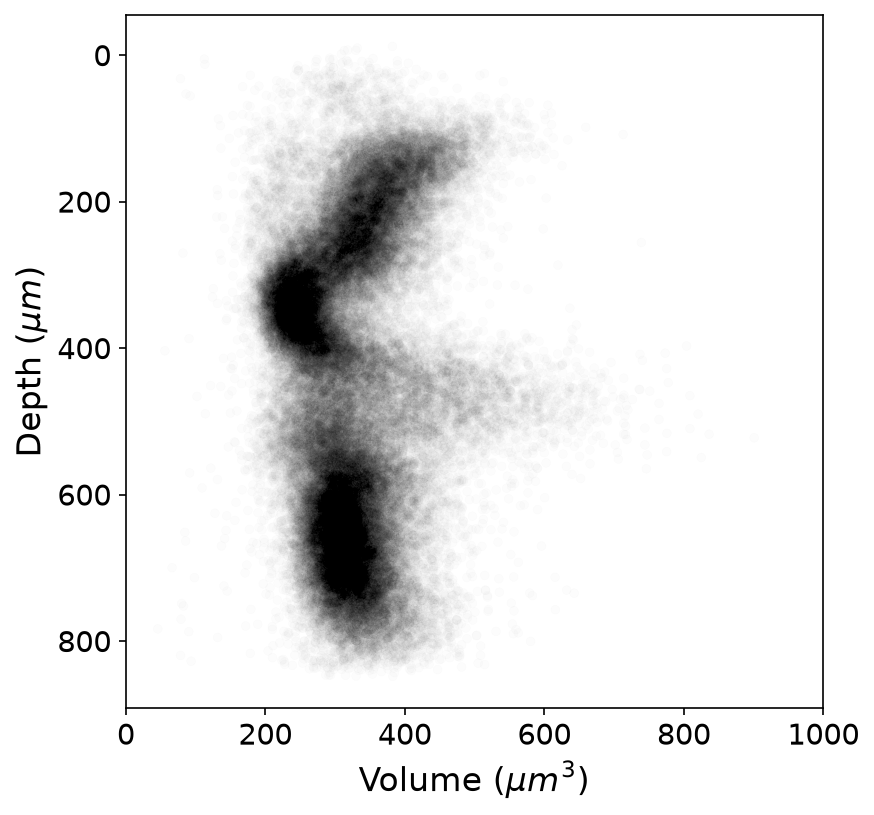

In [58]:
# Figure 5: Spatial Organization of Cell Nuclei in the tissue

# Add a column that is soma depth in consistent units of um
cell_df['depth_um'] = cell_df['soma_transformed_y'] * 1_000 # from mm to um

# Plot cell volume by depth
fig, ax = plt.subplots(figsize=(6, 6), dpi=150)
ax.tick_params(labelsize=14)
sns.scatterplot(
    data=cell_df,
    x="soma_volume",
    y="depth_um",
    size=1,
    edgecolor=None,
    alpha=0.01,
    color="k",
    ax=ax,
    legend=False,
)
ax.invert_yaxis()
ax.set_xlabel(r"Volume ($\mu m^3$)", fontsize=16)
ax.set_ylabel(r"Depth ($\mu m$)", fontsize=16)
ax.set_xlim(0, 1000)
plt.show()

### Using the automated cell types

Many of these automated cell type definitions were established and refined for the [MICrONS Dataset](https://www.microns-explorer.org/) including:

<ul>
    <li> Perisomatic cell features <a href=https://www.nature.com/articles/s41586-024-07765-7>(Elabbady et al.)</a> </li>
    <li> Morphology and connectivity features <a href=https://www.nature.com/articles/s41586-024-07780-8>(Schneider-Mizell et al.)</a> </li>

The process of applying these labels to the V1DD dataset is ongoing, but we will use cell typing from the <code>cell_type_multifeature_v1</code> table which labels cell types according to using soma, nucleus, dendrite, and spine features. 
</ul>

Excitatory neurons are labeled by projection category (IT, ET, NP, CT, and SP for subplate). 

Inhibitory neurons follow labels based on targeting such as ITC (inhibitory targeting), STC (sparsely targeting), PTC (perisomatic targeting), and DTC (dendrite targeting), but might align more with molecular class than exact targeting for a given neuron, particularly among ITC/VIP cells.

*Note:* Cells here without a label will remain black. These are either non-neuronal cells or potential neurons with large segmentation errors that did not pass quality check

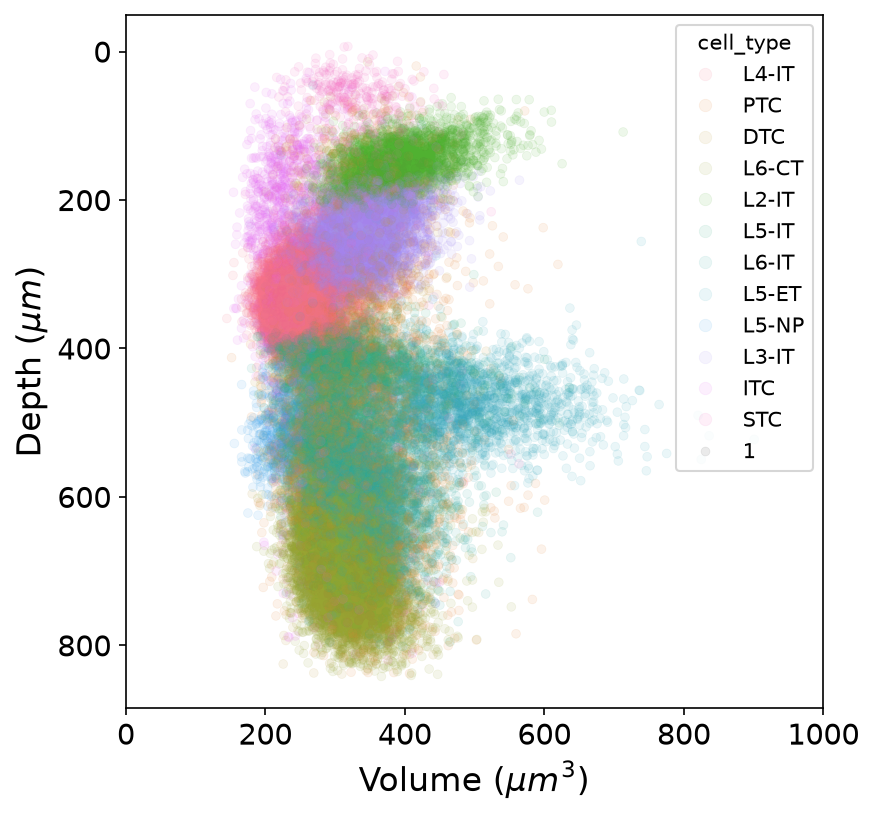

In [60]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=150)
ax.tick_params(labelsize=14)

# Color hue by cell_type 
sns.scatterplot(
    data=cell_df,
    x="soma_volume",
    y="depth_um",
    size=1,
    edgecolor=None,
    alpha=0.1,
    color="k",
    ax=ax,
    legend=True,
    hue="cell_type",
)
ax.invert_yaxis()
ax.set_xlabel(r"Volume ($\mu m^3$)", fontsize=16)
ax.set_ylabel(r"Depth ($\mu m$)", fontsize=16)
ax.set_xlim(0, 1000)
plt.show()

#### Exercise 4: Separate inhibitory and excitatory classes 

Separate this plot by inhibitory and excitatory classes (hint: `cell_type_coarse), as two subplots

Index(['pt_root_id', 'soma_voxel_x', 'soma_voxel_y', 'soma_voxel_z',
       'soma_transformed_x', 'soma_transformed_y', 'soma_transformed_z',
       'soma_volume', 'v1dd_cell_types_level_0', 'cell_type_coarse',
       'cell_type', 'depth_um'],
      dtype='object')
[None 'E' 'I']


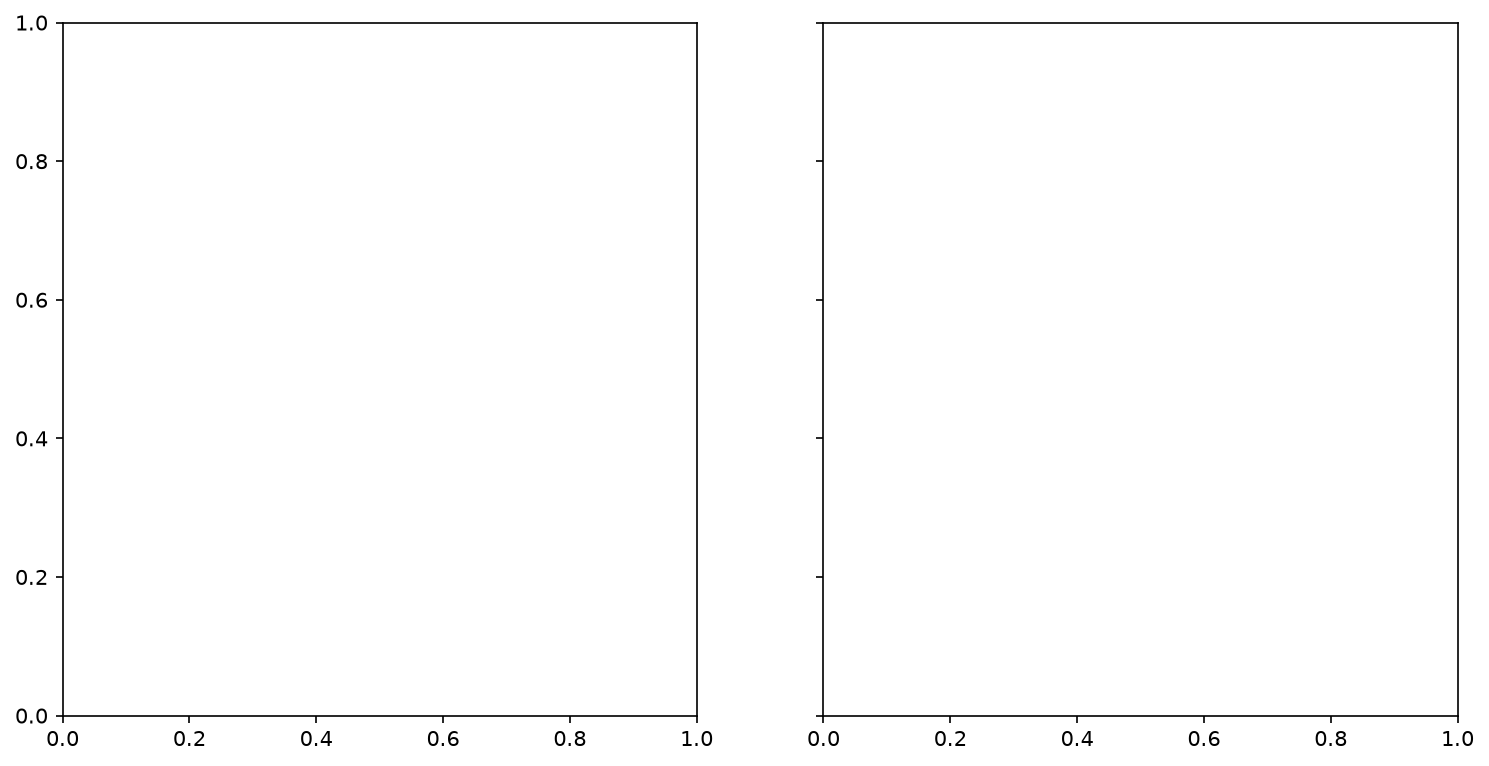

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=150, sharey=True)

print(cell_df.columns)
print(cell_df.cell_type_coarse.unique())

# Excitatory cells
excitatory_cells_df = cell_df.query("cell_type_coarse=='E'")


### Gallery of cell types

!BD TODO

## Interactive session in neuroglancer

Navigation Instructions in the [DataBook: Neuroglancer](https://allenswdb.github.io/anatomy/microns-em/em-neuroglancer.html).

**V1DD Neuroglancer Explorer**: 

> Cell Type Segment Properties : <https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/6528485848776704>

You will be prompted for a google login. Use the same account you used to authenticate your CAVE token


**Bonus Neuroglancer links**:

> Proofreading Status Segment Properties: <https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/5293734357893120>
>
> Synapses with spine/shaft/soma labels (can be slow to load): <https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/5867245166133248>

